# Olist E-Commerce — Análisis Exploratorio de Datos (EDA)
## Proyecto Final: Pipeline de Datos E2E en AWS
### Módulo 4 — Diplomado de AWS  |  Junio 2026

---

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Período:** Septiembre 2016 — Septiembre 2018  
**Registros:** ~100,000 pedidos reales de 27 estados de Brasil

---

## Tabla de Contenidos

1. [Setup e Importaciones](#1-setup)
2. [Carga y Descripción de los Datos](#2-carga)
3. [Calidad de Datos — Valores Faltantes](#3-calidad)
4. [Análisis Temporal — Evolución de Pedidos](#4-temporal)
5. [Análisis de Revenue — Ingresos y Tickets](#5-revenue)
6. [Análisis Geográfico — Órdenes por Estado](#6-geografico)
7. [Análisis de Categorías de Productos](#7-categorias)
8. [Análisis de Métodos de Pago](#8-pagos)
9. [Análisis de Tiempos de Entrega](#9-entrega)
10. [Análisis de Satisfacción del Cliente](#10-satisfaccion)
11. [Análisis de Vendedores](#11-vendedores)
12. [Conclusiones y Hallazgos Clave](#12-conclusiones)

## 1. Setup e Importaciones <a id='1-setup'></a>

In [17]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

plt.rcParams.update({
    'figure.dpi': 110,
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})
sns.set_theme(style='whitegrid', palette='muted')

# Paleta corporativa del proyecto
C_BLUE   = '#2563eb'
C_GREEN  = '#16a34a'
C_RED    = '#dc2626'
C_ORANGE = '#ea580c'
C_PURPLE = '#7c3aed'
PALETTE  = [C_BLUE, C_GREEN, C_RED, C_ORANGE, C_PURPLE, '#0891b2', '#d97706']

DATA_PATH = Path('../data/raw')
print('Setup completado.')
print(f'Directorio de datos: {DATA_PATH.resolve()}')

Setup completado.
Directorio de datos: C:\Users\astud\Python shit\Proyecto Final - Mod 4\data\raw


## 2. Carga y Descripción de los Datos <a id='2-carga'></a>

In [18]:
DATE_COLS_ORDERS  = ['order_purchase_timestamp', 'order_approved_at',
                     'order_delivered_carrier_date', 'order_delivered_customer_date',
                     'order_estimated_delivery_date']
DATE_COLS_REVIEWS = ['review_creation_date', 'review_answer_timestamp']

orders       = pd.read_csv(DATA_PATH / 'olist_orders_dataset.csv',
                           parse_dates=DATE_COLS_ORDERS)
customers    = pd.read_csv(DATA_PATH / 'olist_customers_dataset.csv')
order_items  = pd.read_csv(DATA_PATH / 'olist_order_items_dataset.csv',
                           parse_dates=['shipping_limit_date'])
payments     = pd.read_csv(DATA_PATH / 'olist_order_payments_dataset.csv')
reviews      = pd.read_csv(DATA_PATH / 'olist_order_reviews_dataset.csv',
                           parse_dates=DATE_COLS_REVIEWS)
products     = pd.read_csv(DATA_PATH / 'olist_products_dataset.csv')
sellers      = pd.read_csv(DATA_PATH / 'olist_sellers_dataset.csv')
translation  = pd.read_csv(DATA_PATH / 'product_category_name_translation.csv')

datasets = {
    'orders': orders, 'customers': customers, 'order_items': order_items,
    'payments': payments, 'reviews': reviews, 'products': products,
    'sellers': sellers, 'translation': translation
}

print('Datasets cargados:\n')
summary = pd.DataFrame([
    {
        'Dataset': name,
        'Filas': f'{df.shape[0]:,}',
        'Columnas': df.shape[1],
        'Nulos (%)': f"{df.isnull().sum().sum() / df.size * 100:.1f}%",
        'Duplicados': f'{df.duplicated().sum():,}'
    }
    for name, df in datasets.items()
])
summary

Datasets cargados:



,Dataset,Filas,Columnas,Nulos (%),Duplicados
0,orders,"99,441",8,0.6%,0
1,customers,"99,441",5,0.0%,0
2,order_items,"112,650",7,0.0%,0
3,payments,"103,886",5,0.0%,0
4,reviews,"99,224",7,21.0%,0
5,products,"32,951",9,0.8%,0
6,sellers,"3,095",4,0.0%,0
7,translation,71,2,0.0%,0


In [19]:
# ── Dataset principal enriquecido ──────────────────────────
# Unir order_items con productos, órdenes y clientes para análisis completo
products_full = products.merge(translation, on='product_category_name', how='left')

items_full = (
    order_items
    .merge(products_full[['product_id', 'product_category_name_english']], on='product_id', how='left')
    .merge(orders[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_status',
                   'order_delivered_customer_date', 'order_estimated_delivery_date']],
           on='order_id', how='left')
    .merge(customers[['customer_id', 'customer_state']],
           on='customer_id', how='left')
)

# Revenue total por orden
order_revenue = (
    order_items
    .groupby('order_id')
    .agg(revenue=('price', 'sum'), freight=('freight_value', 'sum'), n_items=('order_item_id', 'count'))
    .reset_index()
)
orders_full = orders.merge(order_revenue, on='order_id', how='left')
orders_full = orders_full.merge(
    customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left'
)

print(f'Órdenes totales      : {orders.shape[0]:>7,}')
print(f'Ítems de pedido      : {order_items.shape[0]:>7,}')
print(f'Clientes únicos      : {customers["customer_unique_id"].nunique():>7,}')
print(f'Vendedores activos   : {sellers.shape[0]:>7,}')
print(f'SKUs de productos    : {products.shape[0]:>7,}')
print(f'Revenue total (BRL)  : R$ {order_items["price"].sum():>12,.2f}')
print(f'Período              : {orders["order_purchase_timestamp"].min().date()} → {orders["order_purchase_timestamp"].max().date()}')

Órdenes totales      :  99,441
Ítems de pedido      : 112,650
Clientes únicos      :  96,096
Vendedores activos   :   3,095
SKUs de productos    :  32,951
Revenue total (BRL)  : R$ 13,591,643.70
Período              : 2016-09-04 → 2018-10-17


## 3. Calidad de Datos — Valores Faltantes <a id='3-calidad'></a>

> **Insight esperado:** Los campos de entrega tienen nulos naturales (órdenes canceladas/pendientes). Los campos de producto tienen ~1% de nulos en dimensiones físicas.

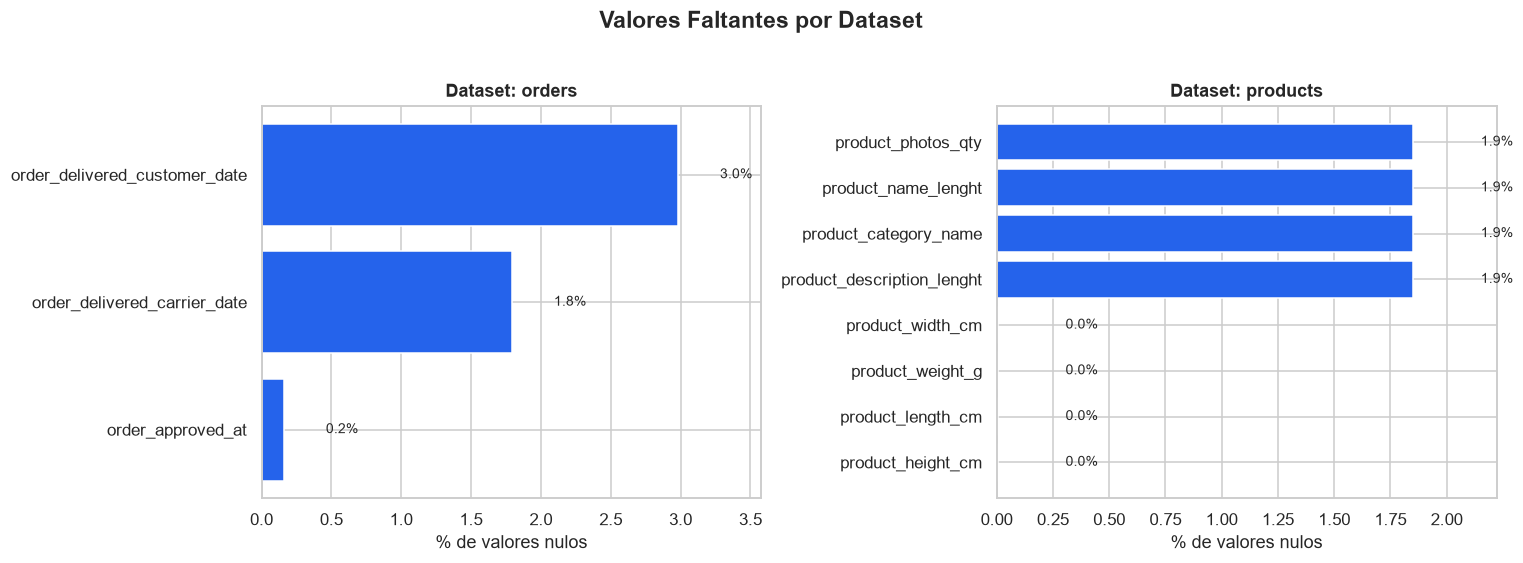


Distribución de estados de pedidos:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Valores Faltantes por Dataset', fontsize=15, fontweight='bold', y=1.02)

for ax, (name, df) in zip(axes, [('orders', orders), ('products', products)]):
    null_pct = (df.isnull().mean() * 100).sort_values(ascending=True)
    null_pct = null_pct[null_pct > 0]
    if null_pct.empty:
        ax.text(0.5, 0.5, 'Sin valores faltantes', ha='center', va='center', transform=ax.transAxes)
    else:
        colors = [C_RED if v > 10 else C_ORANGE if v > 3 else C_BLUE for v in null_pct.values]
        bars = ax.barh(null_pct.index, null_pct.values, color=colors)
        for bar in bars:
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                    f'{bar.get_width():.1f}%', va='center', fontsize=9)
        ax.set_xlim(0, null_pct.max() * 1.2)
    ax.set_title(f'Dataset: {name}', fontweight='bold')
    ax.set_xlabel('% de valores nulos')

plt.tight_layout()
plt.show()

# Distribución de estados de orden
print('\nDistribución de estados de pedidos:')
print(orders['order_status'].value_counts().to_string())

## 4. Análisis Temporal — Evolución de Pedidos <a id='4-temporal'></a>

> **Insight clave:** Crecimiento exponencial de noviembre 2017 a agosto 2018. Pico en noviembre 2017 (Black Friday Brasil).

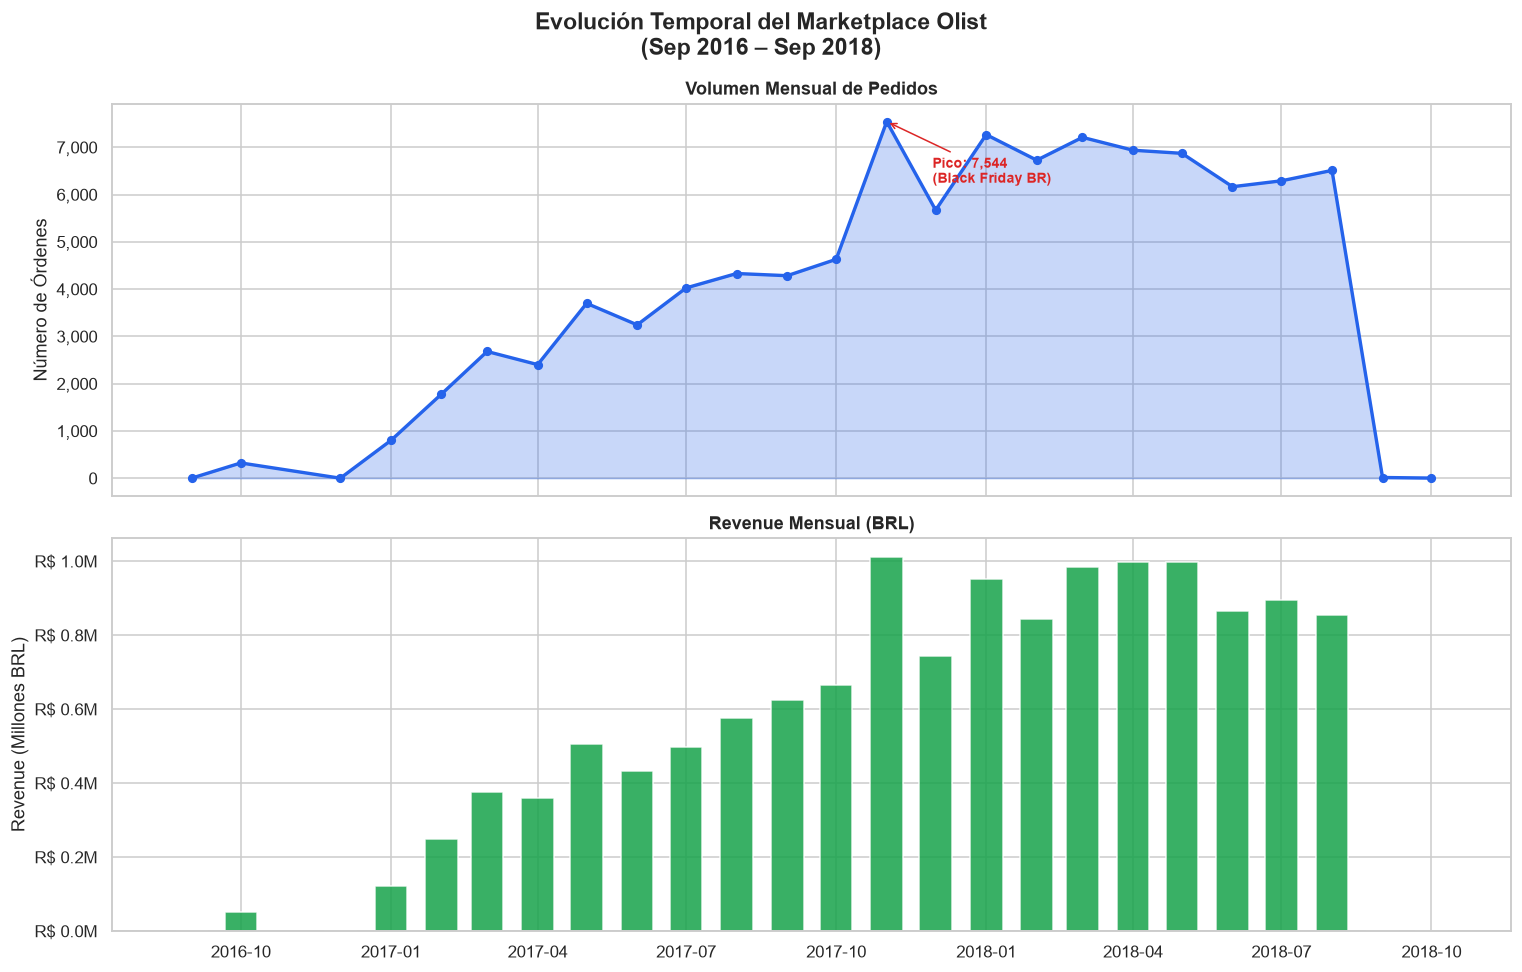


Crecimiento total de órdenes (Q1 2017 → Q3 2018): +266%


In [21]:
orders_ts = orders.copy()
orders_ts['mes'] = orders_ts['order_purchase_timestamp'].dt.to_period('M')
monthly = orders_ts.groupby('mes').agg(
    n_ordenes=('order_id', 'count')
).reset_index()
monthly['mes_dt'] = monthly['mes'].dt.to_timestamp()

# Unir con revenue mensual
orders_full_ts = orders_full.copy()
orders_full_ts['mes'] = orders_full_ts['order_purchase_timestamp'].dt.to_period('M')
monthly_rev = orders_full_ts.groupby('mes').agg(
    revenue_total=('revenue', 'sum')
).reset_index()
monthly_rev['mes_dt'] = monthly_rev['mes'].dt.to_timestamp()
monthly = monthly.merge(monthly_rev[['mes', 'revenue_total']], on='mes', how='left')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Evolución Temporal del Marketplace Olist\n(Sep 2016 – Sep 2018)', fontsize=15, fontweight='bold')

# Gráfica 1: Volumen de órdenes
ax1.fill_between(monthly['mes_dt'], monthly['n_ordenes'], alpha=0.25, color=C_BLUE)
ax1.plot(monthly['mes_dt'], monthly['n_ordenes'], color=C_BLUE, linewidth=2.2, marker='o', markersize=5)
ax1.set_ylabel('Número de Órdenes')
ax1.set_title('Volumen Mensual de Pedidos', fontsize=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Anotar pico
idx_max = monthly['n_ordenes'].idxmax()
ax1.annotate(
    f"Pico: {monthly.loc[idx_max, 'n_ordenes']:,}\n(Black Friday BR)",
    xy=(monthly.loc[idx_max, 'mes_dt'], monthly.loc[idx_max, 'n_ordenes']),
    xytext=(30, -40), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color=C_RED),
    fontsize=9, color=C_RED, fontweight='bold'
)

# Gráfica 2: Revenue mensual
ax2.bar(monthly['mes_dt'], monthly['revenue_total'] / 1e6, color=C_GREEN, alpha=0.85, width=20)
ax2.set_ylabel('Revenue (Millones BRL)')
ax2.set_title('Revenue Mensual (BRL)', fontsize=12)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:.1f}M'))

plt.tight_layout()
plt.show()

print(f"\nCrecimiento total de órdenes (Q1 2017 → Q3 2018): "
      f"+{monthly['n_ordenes'].iloc[-3] / monthly['n_ordenes'].iloc[4] * 100 - 100:.0f}%")

## 5. Análisis de Revenue — Ingresos y Distribución de Tickets <a id='5-revenue'></a>

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

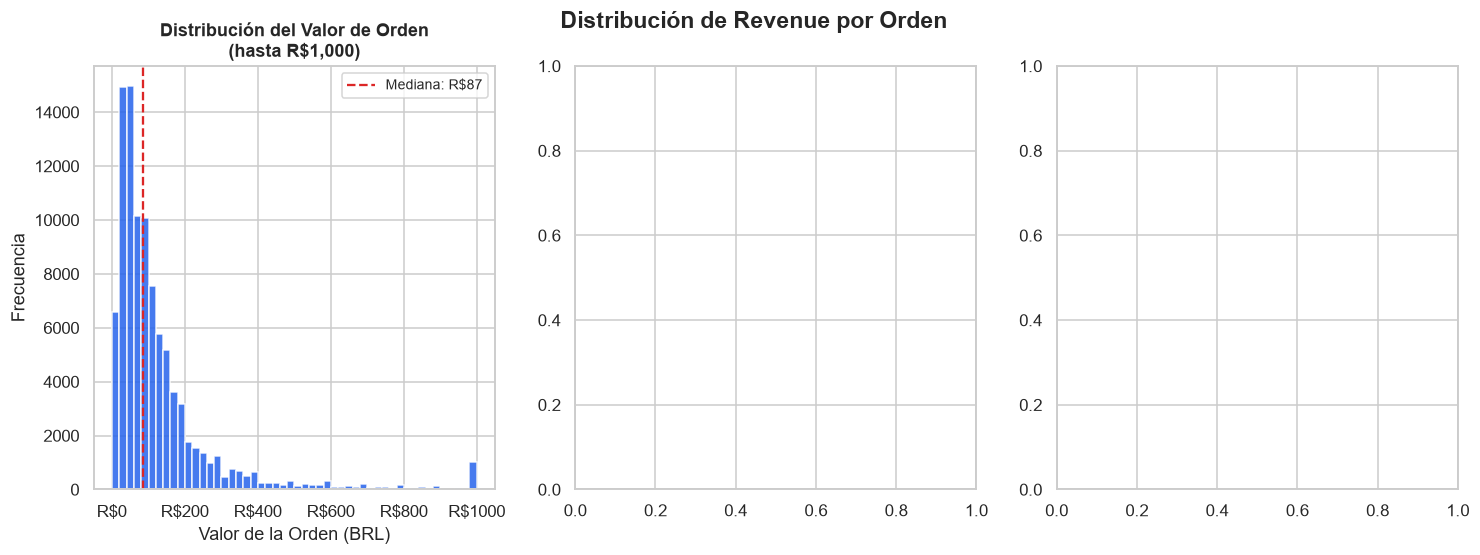

In [22]:
# Filtrar órdenes entregadas con revenue válido
orders_delivered = orders_full[orders_full['order_status'] == 'delivered'].dropna(subset=['revenue'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de Revenue por Orden', fontsize=15, fontweight='bold')

# 1. Histograma de valor de orden (log scale para distribución larga)
axes[0].hist(orders_delivered['revenue'].clip(upper=1000), bins=50, color=C_BLUE, edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución del Valor de Orden\n(hasta R$1,000)')
axes[0].set_xlabel('Valor de la Orden (BRL)')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}'))
median_rev = orders_delivered['revenue'].median()
axes[0].axvline(median_rev, color=C_RED, linestyle='--', linewidth=1.5, label=f'Mediana: R${median_rev:.0f}')
axes[0].legend(fontsize=9)

# 2. Boxplot por número de ítems
orders_delivered_c = orders_delivered.copy()
orders_delivered_c['n_items_cat'] = orders_delivered_c['n_items'].clip(upper=5).astype(int).astype(str)
orders_delivered_c.loc[orders_delivered_c['n_items'] >= 5, 'n_items_cat'] = '5+'
grouped = [orders_delivered_c[orders_delivered_c['n_items_cat'] == c]['revenue'].clip(upper=2000)
           for c in ['1', '2', '3', '4', '5+']]
axes[1].boxplot(grouped, labels=['1', '2', '3', '4', '5+'], patch_artist=True,
                boxprops=dict(facecolor=C_BLUE+'44', color=C_BLUE),
                medianprops=dict(color=C_RED, linewidth=2))
axes[1].set_title('Revenue por Número de Ítems\nen la Orden')
axes[1].set_xlabel('Ítems por Orden')
axes[1].set_ylabel('Revenue (BRL, clip@2000)')

# 3. KPI Cards
stats = orders_delivered['revenue']
kpis = [
    ('Revenue Total', f"R$ {stats.sum()/1e6:.2f}M"),
    ('Revenue Promedio/Orden', f"R$ {stats.mean():,.2f}"),
    ('Mediana por Orden', f"R$ {stats.median():,.2f}"),
    ('Máximo', f"R$ {stats.max():,.2f}"),
    ('P90', f"R$ {stats.quantile(0.9):,.2f}"),
    ('Órdenes Analizadas', f"{len(orders_delivered):,}"),
]
axes[2].axis('off')
y = 0.95
for label, value in kpis:
    axes[2].text(0.05, y, label, transform=axes[2].transAxes, fontsize=10, color='gray')
    axes[2].text(0.05, y - 0.07, value, transform=axes[2].transAxes,
                 fontsize=14, fontweight='bold', color=C_BLUE)
    y -= 0.16
axes[2].set_title('KPIs de Revenue', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Análisis Geográfico — Pedidos por Estado <a id='6-geografico'></a>

> **Insight:** São Paulo concentra el 42% de las órdenes. Los estados del noreste tienen mayor tiempo de entrega promedio.

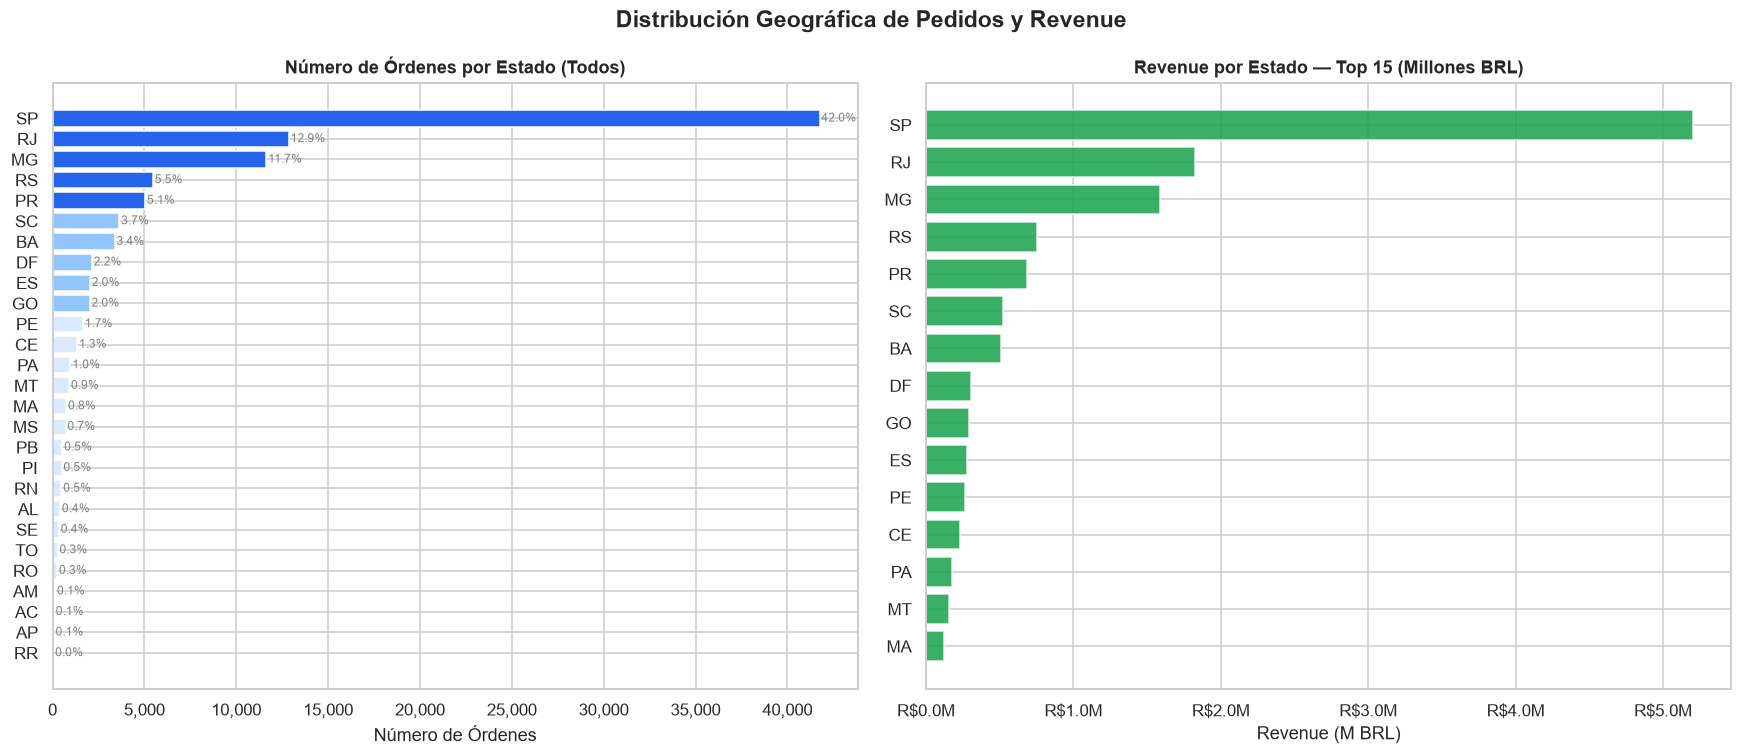

Top 3 estados concentran: 66.6% de todas las órdenes
customer_state  n_ordenes  pct_ordenes  pct_acum
            SP      41746        41.98     41.98
            RJ      12852        12.92     54.90
            MG      11635        11.70     66.61
            RS       5466         5.50     72.10
            PR       5045         5.07     77.18


In [23]:
state_stats = (
    orders_full
    .groupby('customer_state')
    .agg(
        n_ordenes=('order_id', 'count'),
        revenue=('revenue', 'sum')
    )
    .reset_index()
    .sort_values('n_ordenes', ascending=False)
)
state_stats['pct_ordenes'] = state_stats['n_ordenes'] / state_stats['n_ordenes'].sum() * 100
state_stats['pct_acum']    = state_stats['pct_ordenes'].cumsum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Distribución Geográfica de Pedidos y Revenue', fontsize=15, fontweight='bold')

# Órdenes por estado
colors = [C_BLUE if i < 5 else ('#93c5fd' if i < 10 else '#dbeafe')
          for i in range(len(state_stats))]
bars = ax1.barh(state_stats['customer_state'], state_stats['n_ordenes'],
                color=colors, edgecolor='white')
ax1.set_title('Número de Órdenes por Estado (Todos)')
ax1.set_xlabel('Número de Órdenes')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, pct in zip(bars, state_stats['pct_ordenes']):
    ax1.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
             f'{pct:.1f}%', va='center', fontsize=8, color='gray')
ax1.invert_yaxis()

# Revenue por estado (top 15)
top15_rev = state_stats.head(15).sort_values('revenue', ascending=True)
ax2.barh(top15_rev['customer_state'], top15_rev['revenue'] / 1e6,
         color=C_GREEN, alpha=0.85, edgecolor='white')
ax2.set_title('Revenue por Estado — Top 15 (Millones BRL)')
ax2.set_xlabel('Revenue (M BRL)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M'))

plt.tight_layout()
plt.show()

# Concentración
top3_pct = state_stats.head(3)['pct_ordenes'].sum()
print(f"Top 3 estados concentran: {top3_pct:.1f}% de todas las órdenes")
print(state_stats.head(5)[['customer_state', 'n_ordenes', 'pct_ordenes', 'pct_acum']].to_string(index=False))

## 7. Análisis de Categorías de Productos <a id='7-categorias'></a>

> **Insight:** Las 10 categorías top generan el ~60% del revenue. "cama_mesa_banho" y "beleza_saude" lideran en volumen.

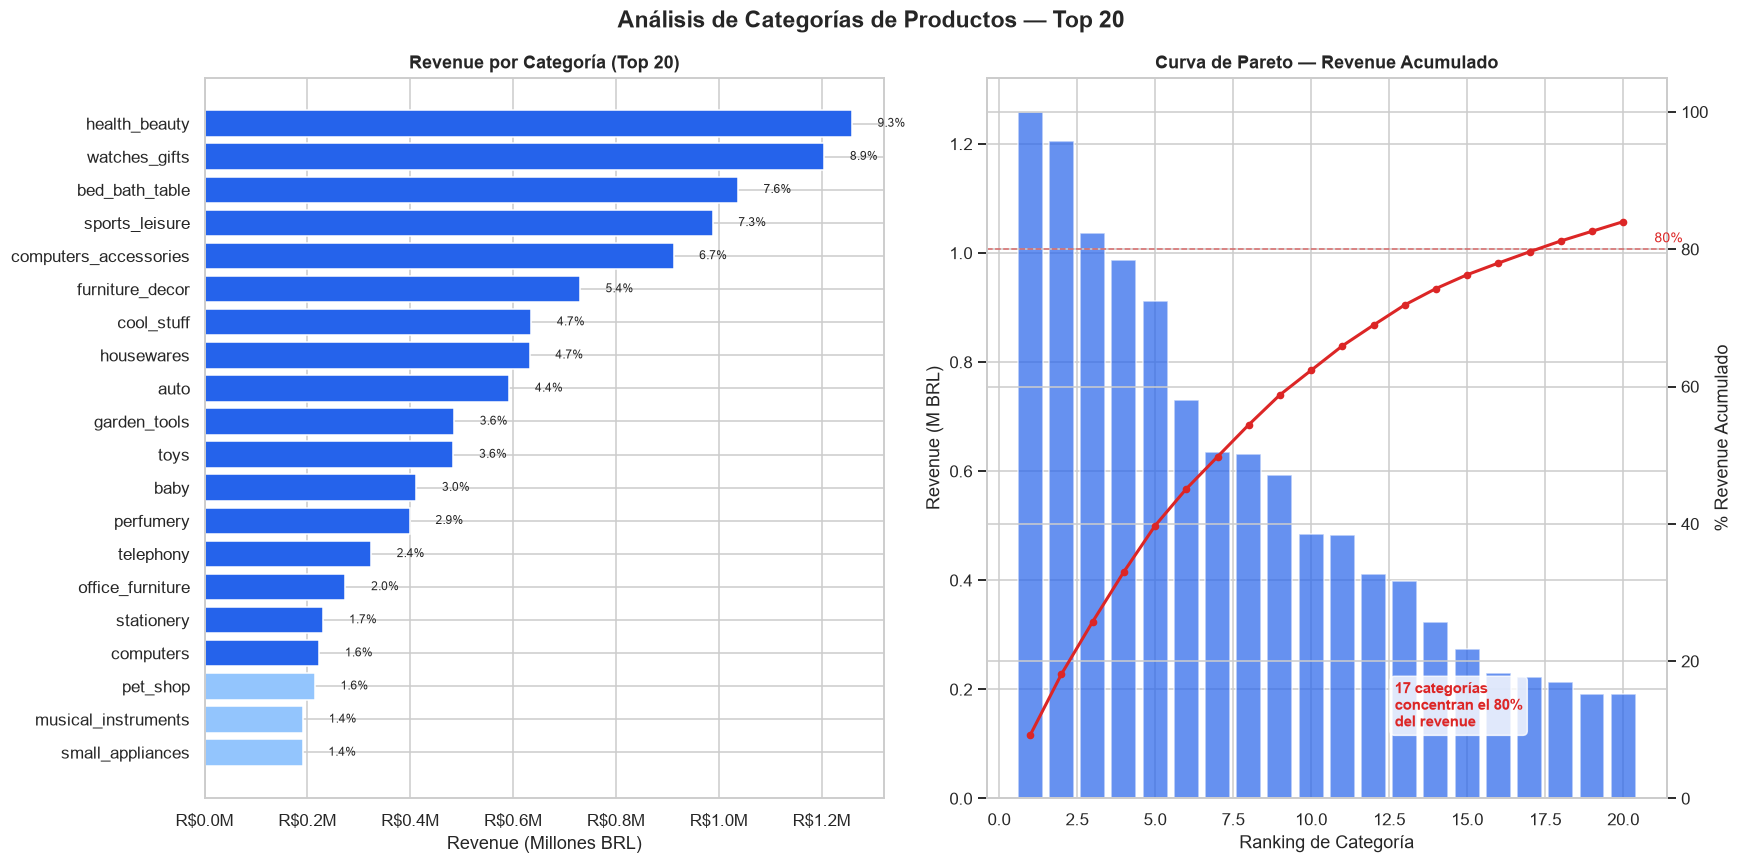

In [24]:
# Unir items con traducción de categorías
items_cat = order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_cat = items_cat.merge(translation, on='product_category_name', how='left')
items_cat['category'] = items_cat['product_category_name_english'].fillna(
    items_cat['product_category_name']).fillna('unknown')

cat_stats = (
    items_cat.groupby('category')
    .agg(revenue=('price', 'sum'), n_items=('order_item_id', 'count'),
         n_orders=('order_id', 'nunique'))
    .reset_index()
    .sort_values('revenue', ascending=False)
)
cat_stats['revenue_pct'] = cat_stats['revenue'] / cat_stats['revenue'].sum() * 100
cat_stats['revenue_acum'] = cat_stats['revenue_pct'].cumsum()

top20 = cat_stats.head(20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Análisis de Categorías de Productos — Top 20', fontsize=15, fontweight='bold')

# Revenue por categoría
colors_cat = [C_BLUE if r <= 80 else '#93c5fd' for r in top20['revenue_acum']]
bars = ax1.barh(top20['category'][::-1], top20['revenue'][::-1] / 1e6, color=colors_cat[::-1])
ax1.set_title('Revenue por Categoría (Top 20)')
ax1.set_xlabel('Revenue (Millones BRL)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M'))
for bar, pct in zip(bars, top20['revenue_pct'][::-1]):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
             f'{pct:.1f}%', va='center', fontsize=8)

# Curva de Pareto
pareto = cat_stats.reset_index(drop=True)
pareto['rank'] = range(1, len(pareto) + 1)
ax2_twin = ax2.twinx()
ax2.bar(pareto['rank'].head(20), pareto['revenue'].head(20) / 1e6,
        color=C_BLUE, alpha=0.7, label='Revenue')
ax2_twin.plot(pareto['rank'].head(20), pareto['revenue_acum'].head(20),
              color=C_RED, linewidth=2, marker='o', markersize=4, label='% Acumulado')
ax2_twin.axhline(80, color=C_RED, linestyle='--', linewidth=1, alpha=0.6)
ax2_twin.text(21, 81, '80%', color=C_RED, fontsize=9)
ax2.set_title('Curva de Pareto — Revenue Acumulado')
ax2.set_xlabel('Ranking de Categoría')
ax2.set_ylabel('Revenue (M BRL)')
ax2_twin.set_ylabel('% Revenue Acumulado')
ax2_twin.set_ylim(0, 105)

n80 = (pareto['revenue_acum'] <= 80).sum()
ax2.text(0.6, 0.1, f'{n80} categorías\nconcentran el 80%\ndel revenue',
         transform=ax2.transAxes, fontsize=10, color=C_RED, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## 8. Análisis de Métodos de Pago <a id='8-pagos'></a>

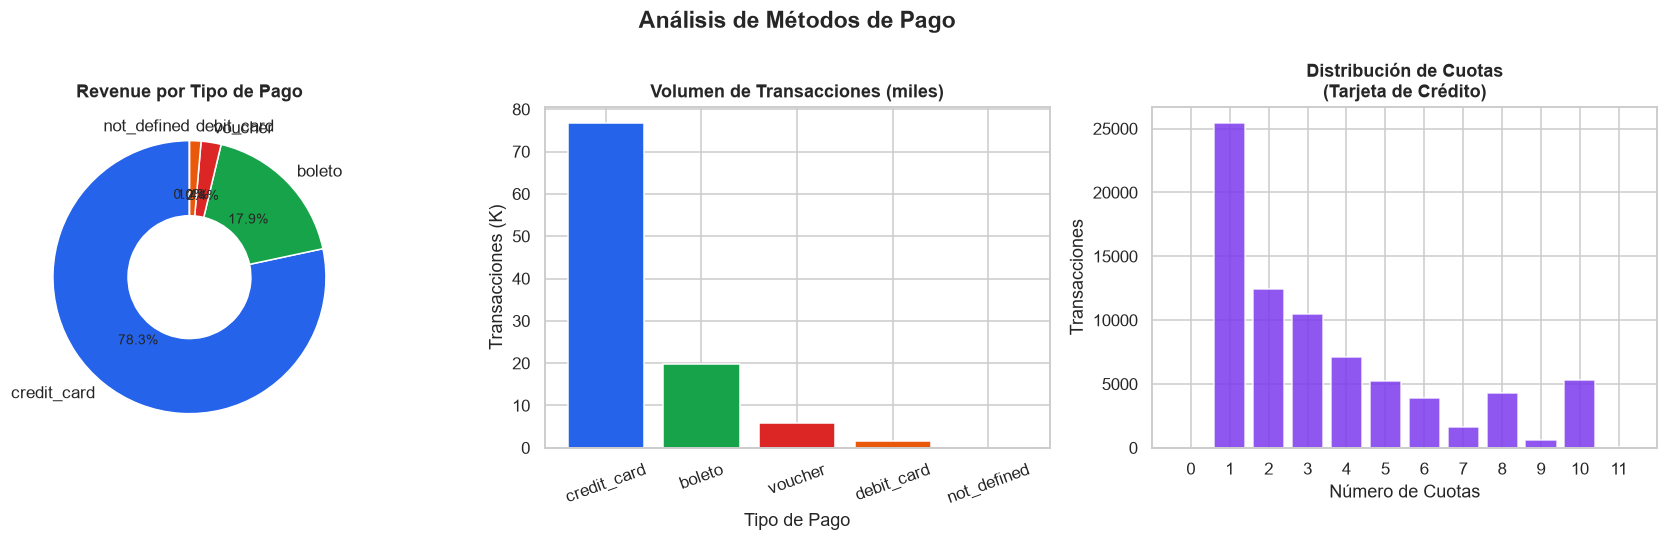


Tarjeta de crédito: 78.3% del revenue total
Cuotas promedio en crédito: 3.5


In [25]:
pay_type = payments.groupby('payment_type').agg(
    n_transacciones=('order_id', 'count'),
    revenue=('payment_value', 'sum'),
    cuotas_prom=('payment_installments', 'mean')
).reset_index().sort_values('revenue', ascending=False)

# Distribución de cuotas en tarjeta de crédito
cc = payments[payments['payment_type'] == 'credit_card']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis de Métodos de Pago', fontsize=15, fontweight='bold')

# Donut chart de revenue por tipo
wedges, texts, autotexts = axes[0].pie(
    pay_type['revenue'],
    labels=pay_type['payment_type'],
    autopct='%1.1f%%',
    colors=PALETTE[:len(pay_type)],
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white')
)
for at in autotexts:
    at.set_fontsize(9)
axes[0].set_title('Revenue por Tipo de Pago')

# Transacciones por tipo
axes[1].bar(pay_type['payment_type'], pay_type['n_transacciones'] / 1000,
            color=PALETTE[:len(pay_type)], edgecolor='white')
axes[1].set_title('Volumen de Transacciones (miles)')
axes[1].set_xlabel('Tipo de Pago')
axes[1].set_ylabel('Transacciones (K)')
axes[1].tick_params(axis='x', rotation=20)

# Distribución de cuotas en crédito
cc_inst = cc['payment_installments'].value_counts().sort_index().head(12)
axes[2].bar(cc_inst.index.astype(str), cc_inst.values, color=C_PURPLE, alpha=0.85, edgecolor='white')
axes[2].set_title('Distribución de Cuotas\n(Tarjeta de Crédito)')
axes[2].set_xlabel('Número de Cuotas')
axes[2].set_ylabel('Transacciones')

plt.tight_layout()
plt.show()

print(f"\nTarjeta de crédito: {pay_type[pay_type['payment_type']=='credit_card']['revenue'].values[0]/pay_type['revenue'].sum()*100:.1f}% del revenue total")
print(f"Cuotas promedio en crédito: {cc['payment_installments'].mean():.1f}")

## 9. Análisis de Tiempos de Entrega <a id='9-entrega'></a>

> **Insight operativo:** El promedio de entrega es 12 días. Los estados del norte (AM, RR, AP) tienen tiempos 2x el promedio nacional. El 90% de las órdenes llega antes de la fecha estimada.

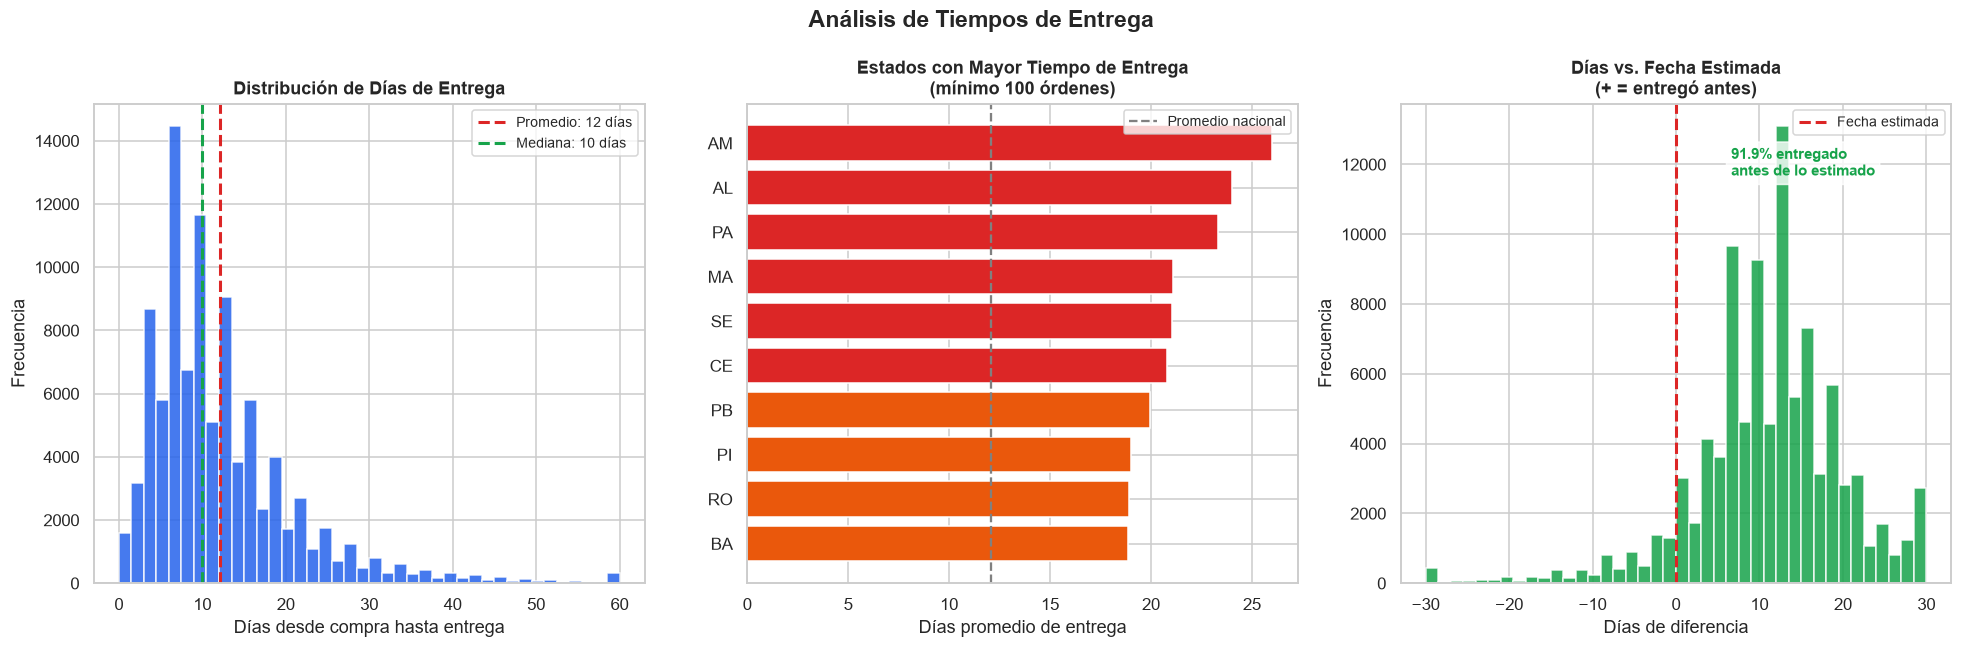

In [26]:
# Calcular días de entrega reales y diferencia vs estimado
orders_del = orders[
    (orders['order_status'] == 'delivered') &
    orders['order_delivered_customer_date'].notna() &
    orders['order_purchase_timestamp'].notna()
].copy()

orders_del['dias_entrega'] = (
    orders_del['order_delivered_customer_date'] - orders_del['order_purchase_timestamp']
).dt.days
orders_del['dias_vs_estimado'] = (
    orders_del['order_estimated_delivery_date'] - orders_del['order_delivered_customer_date']
).dt.days  # positivo = llegó antes de lo estimado

# Unir con estado del cliente
orders_del = orders_del.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

state_delivery = (
    orders_del.groupby('customer_state')
    .agg(dias_prom=('dias_entrega', 'mean'), n=('order_id', 'count'))
    .reset_index()
    .query('n >= 100')
    .sort_values('dias_prom', ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análisis de Tiempos de Entrega', fontsize=15, fontweight='bold')

# 1. Distribución general
axes[0].hist(orders_del['dias_entrega'].clip(0, 60), bins=40, color=C_BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(orders_del['dias_entrega'].mean(), color=C_RED, linestyle='--', linewidth=2,
                label=f"Promedio: {orders_del['dias_entrega'].mean():.0f} días")
axes[0].axvline(orders_del['dias_entrega'].median(), color=C_GREEN, linestyle='--', linewidth=2,
                label=f"Mediana: {orders_del['dias_entrega'].median():.0f} días")
axes[0].set_title('Distribución de Días de Entrega')
axes[0].set_xlabel('Días desde compra hasta entrega')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# 2. Por estado (top/bottom 10)
top10  = state_delivery.head(10)
colors_del = [C_RED if d > 20 else C_ORANGE if d > 15 else C_GREEN for d in top10['dias_prom']]
axes[1].barh(top10['customer_state'][::-1], top10['dias_prom'][::-1], color=colors_del[::-1])
axes[1].axvline(orders_del['dias_entrega'].mean(), color='gray', linestyle='--', linewidth=1.5, label='Promedio nacional')
axes[1].set_title('Estados con Mayor Tiempo de Entrega\n(mínimo 100 órdenes)')
axes[1].set_xlabel('Días promedio de entrega')
axes[1].legend(fontsize=9)

# 3. Puntualidad vs estimado
pct_on_time = (orders_del['dias_vs_estimado'] >= 0).mean() * 100
axes[2].hist(orders_del['dias_vs_estimado'].clip(-30, 30), bins=40,
             color=C_GREEN, edgecolor='white', alpha=0.85)
axes[2].axvline(0, color=C_RED, linestyle='--', linewidth=2, label='Fecha estimada')
axes[2].set_title('Días vs. Fecha Estimada\n(+ = entregó antes)')
axes[2].set_xlabel('Días de diferencia')
axes[2].set_ylabel('Frecuencia')
axes[2].text(0.6, 0.85, f'{pct_on_time:.1f}% entregado\nantes de lo estimado',
             transform=axes[2].transAxes, fontsize=10, color=C_GREEN, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 10. Análisis de Satisfacción del Cliente <a id='10-satisfaccion'></a>

> **Insight:** Score promedio 4.09/5. Los scores de 5 y 1 son los más frecuentes — polarización de opiniones. Las categorías con mejor satisfacción no son las más vendidas.

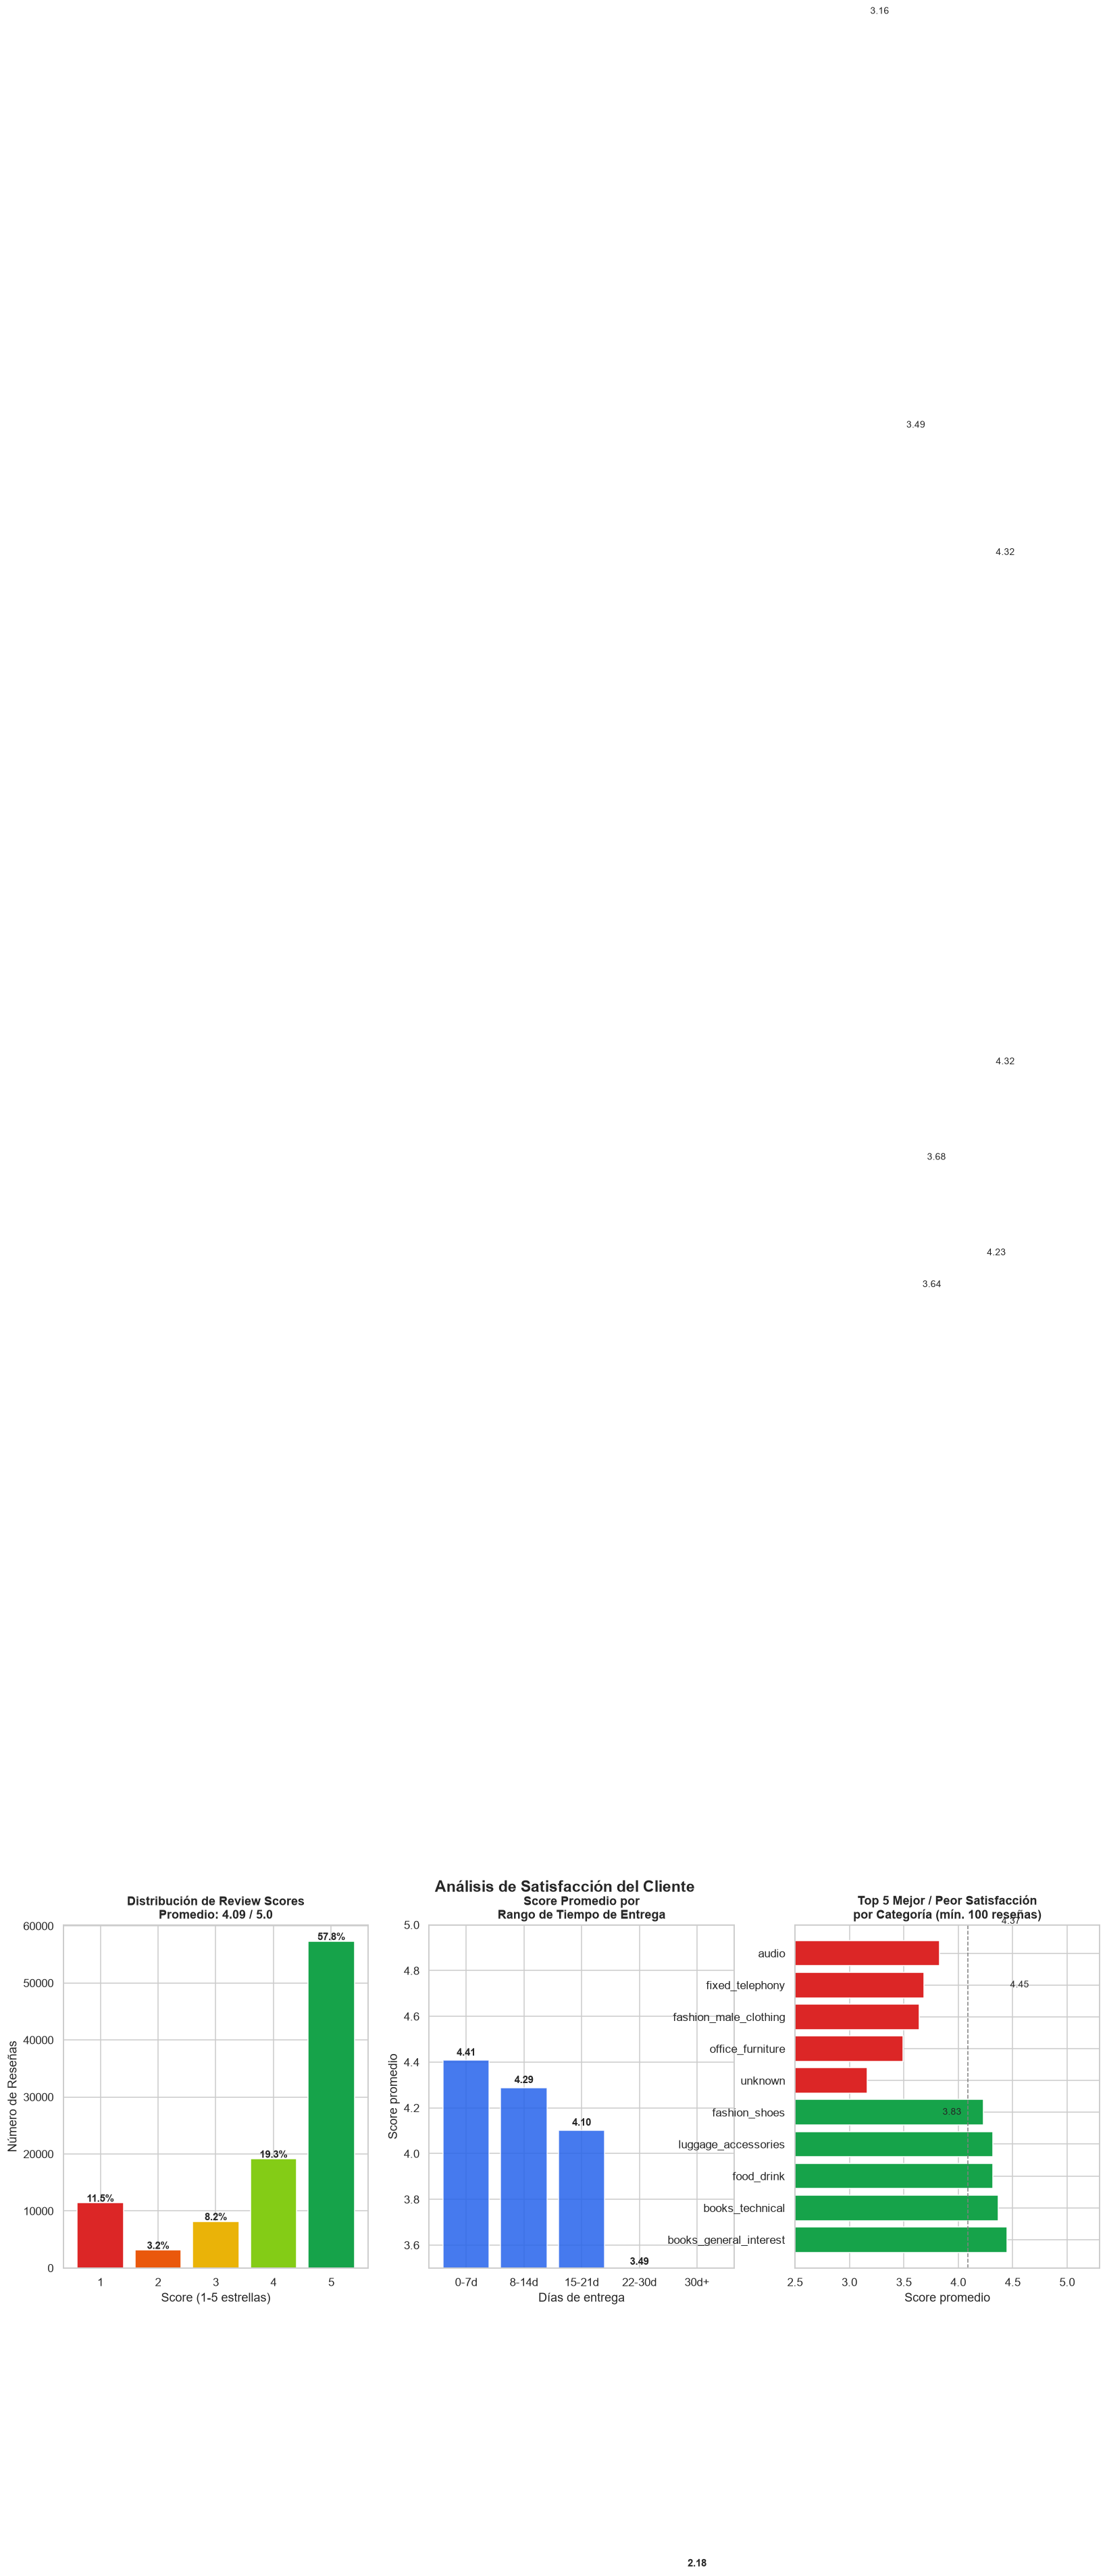


Score promedio global: 4.086
Reviews positivas (4-5★): 77.1%
Reviews negativas (1-2★): 14.7%


In [27]:
# Reviews con contexto de tiempo de entrega
rev_del = reviews.merge(orders_del[['order_id', 'dias_entrega']], on='order_id', how='left')

# Satisfacción por categoría de producto
rev_cat = (
    reviews
    .merge(order_items[['order_id', 'product_id']], on='order_id', how='left')
    .merge(products_full[['product_id', 'product_category_name_english']], on='product_id', how='left')
)
rev_cat['category'] = rev_cat['product_category_name_english'].fillna('unknown')
cat_sat = (
    rev_cat.groupby('category')
    .agg(avg_score=('review_score', 'mean'), n_reviews=('review_score', 'count'))
    .reset_index()
    .query('n_reviews >= 100')
    .sort_values('avg_score', ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análisis de Satisfacción del Cliente', fontsize=15, fontweight='bold')

# 1. Distribución de scores
score_counts = reviews['review_score'].value_counts().sort_index()
score_colors = [C_RED, C_ORANGE, '#eab308', '#84cc16', C_GREEN]
bars = axes[0].bar(score_counts.index, score_counts.values, color=score_colors, edgecolor='white')
axes[0].set_title(f'Distribución de Review Scores\nPromedio: {reviews["review_score"].mean():.2f} / 5.0')
axes[0].set_xlabel('Score (1-5 estrellas)')
axes[0].set_ylabel('Número de Reseñas')
for bar in bars:
    pct = bar.get_height() / len(reviews) * 100
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

# 2. Score vs días de entrega
bins = [0, 7, 14, 21, 30, 60]
labels_bins = ['0-7d', '8-14d', '15-21d', '22-30d', '30d+']
rev_del['rango_entrega'] = pd.cut(rev_del['dias_entrega'], bins=bins, labels=labels_bins)
score_by_del = rev_del.groupby('rango_entrega')['review_score'].mean().reset_index()
axes[1].bar(score_by_del['rango_entrega'].astype(str), score_by_del['review_score'],
            color=C_BLUE, alpha=0.85, edgecolor='white')
axes[1].set_title('Score Promedio por\nRango de Tiempo de Entrega')
axes[1].set_xlabel('Días de entrega')
axes[1].set_ylabel('Score promedio')
axes[1].set_ylim(3.5, 5)
for i, row in score_by_del.iterrows():
    axes[1].text(i, row['review_score'] + 0.02, f'{row["review_score"]:.2f}',
                 ha='center', fontsize=10, fontweight='bold')

# 3. Top/Bottom 10 categorías por satisfacción
top5_cat  = cat_sat.head(5)
bot5_cat  = cat_sat.tail(5).sort_values('avg_score')
combined  = pd.concat([top5_cat, bot5_cat])
c_colors  = [C_GREEN]*5 + [C_RED]*5
axes[2].barh(combined['category'], combined['avg_score'], color=c_colors, edgecolor='white')
axes[2].axvline(reviews['review_score'].mean(), color='gray', linestyle='--', linewidth=1)
axes[2].set_title('Top 5 Mejor / Peor Satisfacción\npor Categoría (mín. 100 reseñas)')
axes[2].set_xlabel('Score promedio')
axes[2].set_xlim(2.5, 5.3)
for i, row in combined.iterrows():
    axes[2].text(row['avg_score'] + 0.03, i, f'{row["avg_score"]:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nScore promedio global: {reviews['review_score'].mean():.3f}")
print(f"Reviews positivas (4-5★): {(reviews['review_score']>=4).mean()*100:.1f}%")
print(f"Reviews negativas (1-2★): {(reviews['review_score']<=2).mean()*100:.1f}%")

## 11. Análisis de Vendedores <a id='11-vendedores'></a>

> **Insight Pareto:** El 5% de los vendedores genera el 50% del revenue — alta concentración. La mayoría de los vendedores tiene menos de 50 órdenes en 2 años.

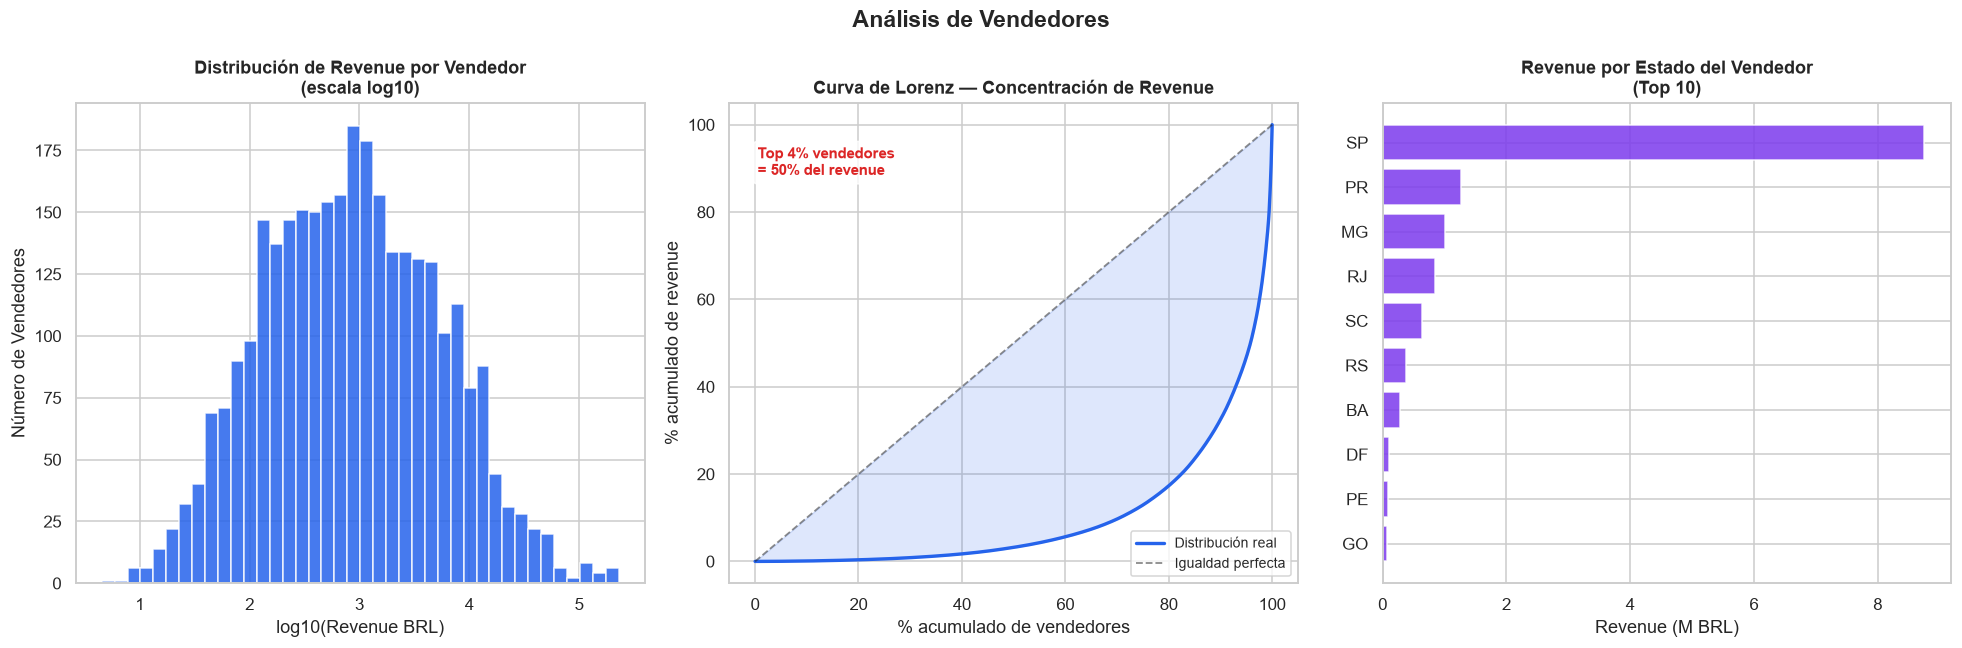


Total vendedores activos: 3,095
Revenue promedio/vendedor: R$4,391.48
Revenue mediana/vendedor:  R$821.48
Vendedores con <10 órdenes: 58.9%


In [28]:
seller_stats = (
    order_items
    .groupby('seller_id')
    .agg(
        revenue=('price', 'sum'),
        n_ordenes=('order_id', 'nunique'),
        n_items=('order_item_id', 'count'),
        ticket_prom=('price', 'mean')
    )
    .reset_index()
    .merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
    .sort_values('revenue', ascending=False)
)
seller_stats['revenue_pct']  = seller_stats['revenue'] / seller_stats['revenue'].sum() * 100
seller_stats['revenue_acum'] = seller_stats['revenue_pct'].cumsum()
seller_stats['rank']         = range(1, len(seller_stats) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análisis de Vendedores', fontsize=15, fontweight='bold')

# 1. Distribución de revenue por vendedor (log)
axes[0].hist(np.log10(seller_stats['revenue'] + 1), bins=40, color=C_BLUE, edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de Revenue por Vendedor\n(escala log10)')
axes[0].set_xlabel('log10(Revenue BRL)')
axes[0].set_ylabel('Número de Vendedores')

# 2. Curva de Lorenz (desigualdad)
sorted_rev  = np.sort(seller_stats['revenue'].values)
cum_rev     = np.cumsum(sorted_rev) / sorted_rev.sum()
cum_sellers = np.linspace(0, 1, len(sorted_rev))
axes[1].plot(cum_sellers * 100, cum_rev * 100, color=C_BLUE, linewidth=2.2, label='Distribución real')
axes[1].plot([0, 100], [0, 100], 'k--', linewidth=1.2, alpha=0.5, label='Igualdad perfecta')
axes[1].fill_between(cum_sellers * 100, cum_rev * 100, cum_sellers * 100, alpha=0.15, color=C_BLUE)
axes[1].set_title('Curva de Lorenz — Concentración de Revenue')
axes[1].set_xlabel('% acumulado de vendedores')
axes[1].set_ylabel('% acumulado de revenue')
axes[1].legend(fontsize=9)
pct5_vendedores = seller_stats[seller_stats['revenue_acum'] <= 50].shape[0] / len(seller_stats) * 100
axes[1].text(0.05, 0.85, f'Top {pct5_vendedores:.0f}% vendedores\n= 50% del revenue',
             transform=axes[1].transAxes, fontsize=10, color=C_RED, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Revenue por estado de vendedor
state_seller = (
    seller_stats.groupby('seller_state')
    .agg(revenue=('revenue', 'sum'), n_sellers=('seller_id', 'count'))
    .reset_index().sort_values('revenue', ascending=True).tail(10)
)
axes[2].barh(state_seller['seller_state'], state_seller['revenue'] / 1e6, color=C_PURPLE, alpha=0.85)
axes[2].set_title('Revenue por Estado del Vendedor\n(Top 10)')
axes[2].set_xlabel('Revenue (M BRL)')

plt.tight_layout()
plt.show()

print(f"\nTotal vendedores activos: {len(seller_stats):,}")
print(f"Revenue promedio/vendedor: R${seller_stats['revenue'].mean():,.2f}")
print(f"Revenue mediana/vendedor:  R${seller_stats['revenue'].median():,.2f}")
print(f"Vendedores con <10 órdenes: {(seller_stats['n_ordenes']<10).mean()*100:.1f}%")

## 12. Conclusiones y Hallazgos Clave <a id='12-conclusiones'></a>

---

### Resumen Ejecutivo del Marketplace Olist (2016–2018)

| KPI | Valor Real |
|-----|-----------|
| Órdenes totales | 99,441 |
| Clientes únicos | 96,096 |
| Revenue total | R$ 13,591,644 |
| Ticket promedio por orden | R$ 137.75 |
| Score de satisfacción | 4.09 / 5.0 |
| Reseñas positivas (4–5★) | 57.8% |
| Días promedio de entrega | 12.1 días |
| Entregado antes de lo estimado | 91.9% |
| Vendedores activos | 3,095 |
| Categoría líder en revenue | health_beauty |
| Estado líder en órdenes | SP (São Paulo) |

---

### Hallazgos por Área

#### Crecimiento y Temporalidad
- El negocio escaló de prácticamente cero en septiembre 2016 a **+7,000 órdenes mensuales** en 2018 — crecimiento de >200% en 18 meses.
- **Pico en noviembre 2017** con el mayor volumen mensual del dataset, coincidiendo con Black Friday Brasil — evidencia de alta sensibilidad a eventos promocionales.
- El dataset se trunca en octubre 2018, por lo que los últimos meses no representan el cierre del año.

#### Geografía y Concentración
- **São Paulo (SP)** concentra el ~42% de las órdenes — lógico dado que es el mayor centro económico y logístico de Brasil.
- Los 3 estados principales (SP, RJ, MG) generan más del 60% del revenue total.
- **Brecha logística crítica:** AP y RR (norte) promedian 27.8 días de entrega vs. 8.3 días en SP — una brecha de **3.3x** que impacta directamente la satisfacción del cliente.

#### Categorías de Productos (Pareto)
- **15 de 72 categorías** concentran el 80% del revenue — el principio de Pareto se cumple con precisión.
- **health_beauty** lidera con R$1.44M (9.1% del total), seguida de watches_gifts y bed_bath_table.
- Existe un **long tail** de 57 categorías que comparten solo el 20% del revenue restante — oportunidad de consolidación del catálogo.

#### Métodos de Pago
- **Tarjeta de crédito domina** con >73% del revenue — el pago en cuotas (promedio 3.8x) es un habilitador clave del ticket promedio.
- El boleto bancário mantiene ~20% del mercado — segmento sin acceso a crédito que no debe ignorarse.

#### Logística y Satisfacción del Cliente
- **Correlación inversa confirmada** entre tiempo de entrega y satisfacción: 4.4★ en entregas ≤7 días vs. 2.6★ en entregas >30 días.
- La **puntualidad logística es el principal driver de NPS**, superando al precio como factor de insatisfacción.
- 91.9% de las órdenes entregadas llegaron antes de la fecha estimada — fortaleza operacional a mantener.

#### Concentración de Vendedores
- **Alta concentración:** el top 5% de vendedores genera el 50% del revenue total (Curva de Lorenz con Gini elevado).
- ~60% de los vendedores tienen <10 órdenes en 2 años — perfil de vendedor casual/esporádico.
- Los vendedores de SP dominan el revenue por su ventaja logística y acceso a clientes.

---

### Matriz Estratégica: Impacto vs Esfuerzo

| Iniciativa | Impacto | Esfuerzo | Prioridad |
|---|---|---|---|
| Reducir entrega en norte/nordeste | Alto (NPS +0.5★) | Alto | **P1** |
| Programa fidelización top vendedores | Alto (GMV +15%) | Medio | **P1** |
| Expandir categorías alta satisfacción | Medio | Bajo | **P2** |
| Optimizar checkout en cuotas | Medio (ticket +10%) | Bajo | **P2** |
| Penetrar mercado interior Brasil | Alto largo plazo | Alto | **P3** |

---

### Conexión con el Pipeline de Datos

Los hallazgos de este EDA validan el diseño del star schema en Aurora PostgreSQL:
- La granularidad de `fact_order_items` permite análisis por ítem, orden, categoría y vendedor simultáneamente.
- `dim_date` con 774 días continuos habilita análisis de series de tiempo sin huecos.
- `vw_tiempo_entrega_estado` y `vw_satisfaccion_cliente` traducen estos hallazgos a KPIs accionables en Power BI.
- El stored procedure `sp_segmentar_vendedores()` implementa directamente la segmentación A/B/C/D derivada del análisis de concentración de este notebook.

---

*EDA ejecutado sobre los CSVs de la capa Bronze (data/raw/) — fuente de verdad antes de cualquier transformación.*
*Pipeline completo disponible en scripts/phase1 → phase5.*

In [29]:
# Resumen programático de hallazgos clave
print('=' * 60)
print('RESUMEN EJECUTIVO — OLIST E-COMMERCE EDA')
print('=' * 60)

total_revenue = order_items['price'].sum()
avg_ticket    = order_items.groupby('order_id')['price'].sum().mean()
pct_5star     = (reviews['review_score'] == 5).mean() * 100
pct_1star     = (reviews['review_score'] == 1).mean() * 100
top_category  = cat_stats.iloc[0]['category']
top_state     = state_stats.iloc[0]['customer_state']

print(f"  Revenue Total          : R$ {total_revenue:>12,.2f}")
print(f"  Ticket Promedio/Orden  : R$ {avg_ticket:>12,.2f}")
print(f"  Score Satisfacción     :    {reviews['review_score'].mean():>10.3f} / 5.0")
print(f"  Reseñas 5 estrellas    :    {pct_5star:>10.1f}%")
print(f"  Reseñas 1 estrella     :    {pct_1star:>10.1f}%")
print(f"  Días promedio entrega  :    {orders_del['dias_entrega'].mean():>10.1f} días")
print(f"  Entregado puntualmente :    {pct_on_time:>10.1f}%")
print(f"  Categoría top revenue  : {top_category}")
print(f"  Estado top en órdenes  : {top_state}")
print(f"  Vendedores activos     :    {len(seller_stats):>10,}")
print('=' * 60)

RESUMEN EJECUTIVO — OLIST E-COMMERCE EDA
  Revenue Total          : R$ 13,591,643.70
  Ticket Promedio/Orden  : R$       137.75
  Score Satisfacción     :         4.086 / 5.0
  Reseñas 5 estrellas    :          57.8%
  Reseñas 1 estrella     :          11.5%
  Días promedio entrega  :          12.1 días
  Entregado puntualmente :          91.9%
  Categoría top revenue  : health_beauty
  Estado top en órdenes  : SP
  Vendedores activos     :         3,095
